In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score
)
import os, json

DATA_DIR  = "../data"
MODEL_DIR = "../models"
FIG_DIR   = "../paper/images"
os.makedirs(FIG_DIR, exist_ok=True)


I0000 00:00:1774138086.977412   33527 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774138086.977760   33527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774138087.009554   33527 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774138088.039584   33527 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
def load_model_compat(model_path):
    # Compatibility patch for legacy Lambda deserialization (shape inference).
    original_compute_output_shape = tf.keras.layers.Lambda.compute_output_shape

    def _patched_compute_output_shape(self, input_shape):
        try:
            return original_compute_output_shape(self, input_shape)
        except NotImplementedError:
            shape = input_shape
            if isinstance(shape, list) and len(shape) == 1:
                shape = shape[0]
            if isinstance(shape, tuple) and len(shape) == 3:
                # For attn_context: (batch, timesteps, features) -> (batch, features)
                return (shape[0], shape[2])
            return shape

    tf.keras.layers.Lambda.compute_output_shape = _patched_compute_output_shape
    model = tf.keras.models.load_model(model_path, compile=False, safe_mode=False)

    # Ensure lambda globals include tensorflow for runtime execution.
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Lambda):
            layer.function.__globals__['tf'] = tf

    return model


model = load_model_compat(f"{MODEL_DIR}/best_model.keras")
THRESHOLD = float(np.load(f"{MODEL_DIR}/best_threshold.npy")[0])

X_test = np.load(f"{DATA_DIR}/X_test.npy")
y_test = np.load(f"{DATA_DIR}/y_test.npy")

y_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_proba >= THRESHOLD).astype(int)

print("Model loaded")
print(f"Threshold        : {THRESHOLD:.4f}")
print(f"Test windows     : {len(X_test)}")
print(f"Test leaks       : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

E0000 00:00:1774138088.205293   33527 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded
Threshold        : 0.0200
Test windows     : 221
Test leaks       : 91 (41.2%)


In [3]:
auc_roc = roc_auc_score(y_test, y_proba)
auc_pr  = average_precision_score(y_test, y_proba)
report  = classification_report(y_test, y_pred,
            target_names=["Normal", "Leak"], digits=4, output_dict=True)

print("=" * 45)
print("       FINAL TEST SET RESULTS")
print("=" * 45)
print(f"  AUC-ROC        : {auc_roc:.4f}")
print(f"  AUC-PR         : {auc_pr:.4f}")
print(f"  Threshold      : {THRESHOLD:.4f}")
print("-" * 45)
print(f"  Leak Precision : {report['Leak']['precision']:.4f}")
print(f"  Leak Recall    : {report['Leak']['recall']:.4f}")
print(f"  Leak F1        : {report['Leak']['f1-score']:.4f}")
print(f"  Accuracy       : {report['accuracy']:.4f}")
print("=" * 45)

# Save as CSV for easy paper copy-paste
metrics_df = pd.DataFrame({
    "Metric": ["AUC-ROC", "AUC-PR", "Precision (Leak)",
               "Recall (Leak)", "F1 (Leak)", "Accuracy"],
    "Value":  [round(auc_roc, 4), round(auc_pr, 4),
               round(report['Leak']['precision'], 4),
               round(report['Leak']['recall'], 4),
               round(report['Leak']['f1-score'], 4),
               round(report['accuracy'], 4)]
})
metrics_df.to_csv(f"{DATA_DIR}/final_metrics.csv", index=False)
print("\n Saved → data/final_metrics.csv")


       FINAL TEST SET RESULTS
  AUC-ROC        : 0.5011
  AUC-PR         : 0.4552
  Threshold      : 0.0200
---------------------------------------------
  Leak Precision : 0.4118
  Leak Recall    : 1.0000
  Leak F1        : 0.5833
  Accuracy       : 0.4118

 Saved → data/final_metrics.csv


/home/regisx001/DeepLearning-Water-leaks-detection/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/regisx001/DeepLearning-Water-leaks-detection/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/regisx001/DeepLearning-Water-leaks-detection/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

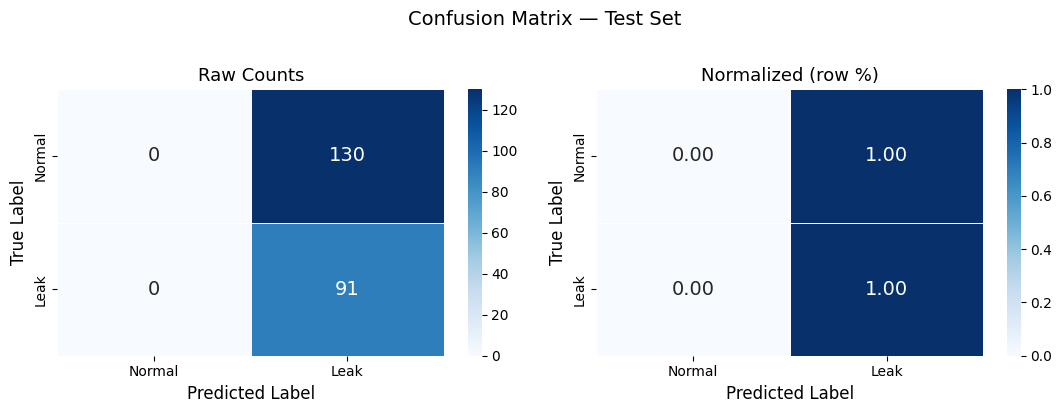

 Saved → fig_confusion_matrix.png


In [4]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, fmt, title in zip(
    axes,
    [cm,      cm_norm],
    ["d",     ".2f"],
    ["Raw Counts", "Normalized (row %)"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=["Normal", "Leak"],
                yticklabels=["Normal", "Leak"],
                linewidths=0.5, ax=ax,
                annot_kws={"size": 14})
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label",      fontsize=12)
    ax.set_title(title,              fontsize=13)

plt.suptitle("Confusion Matrix — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print(" Saved → fig_confusion_matrix.png")


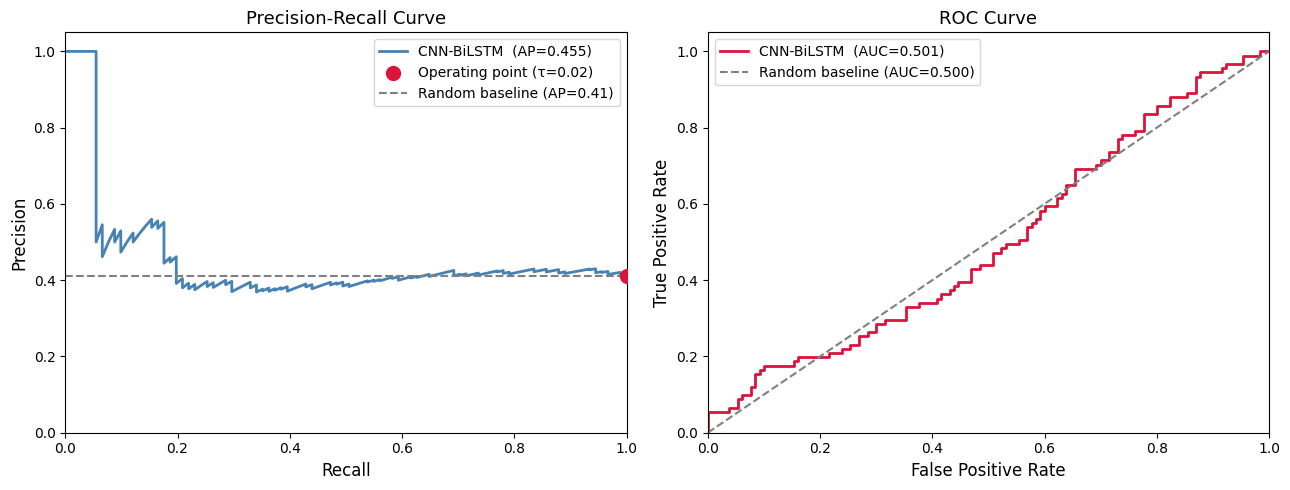

 Saved → fig_pr_roc_curves.png


In [5]:
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
fpr, tpr, _                              = roc_curve(y_test, y_proba)

# Find operating point on PR curve
op_idx = np.argmin(np.abs(thresholds_pr - THRESHOLD))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── PR Curve ──────────────────────────────────────────────────────
axes[0].plot(recall_arr, precision_arr, color="steelblue", lw=2,
             label=f"CNN-BiLSTM  (AP={auc_pr:.3f})")
axes[0].scatter(recall_arr[op_idx], precision_arr[op_idx],
                color="crimson", zorder=5, s=100,
                label=f"Operating point (τ={THRESHOLD:.2f})")
axes[0].axhline(y_test.mean(), linestyle="--", color="gray",
                label=f"Random baseline (AP={y_test.mean():.2f})")
axes[0].set_xlabel("Recall",    fontsize=12)
axes[0].set_ylabel("Precision", fontsize=12)
axes[0].set_title("Precision-Recall Curve", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])

# ── ROC Curve ─────────────────────────────────────────────────────
axes[1].plot(fpr, tpr, color="crimson", lw=2,
             label=f"CNN-BiLSTM  (AUC={auc_roc:.3f})")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray",
             label="Random baseline (AUC=0.500)")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate",  fontsize=12)
axes[1].set_title("ROC Curve",            fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_pr_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(" Saved → fig_pr_roc_curves.png")


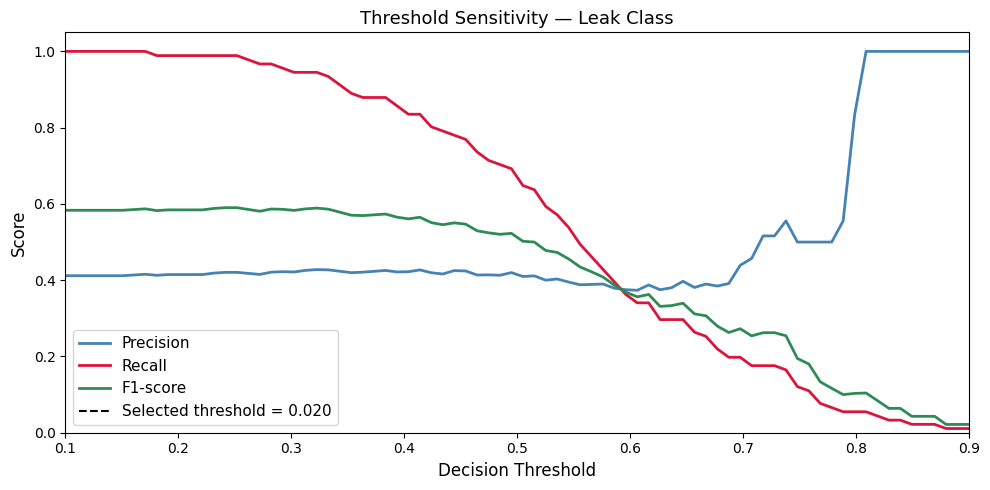

 Saved → fig_threshold_sensitivity.png


In [6]:
# Show how Precision, Recall, F1 change with threshold
thresh_range  = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s = [], [], []

for t in thresh_range:
    yp = (y_proba >= t).astype(int)
    if yp.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue
    p = report['Leak']['precision'] if t == THRESHOLD else \
        (y_test * yp).sum() / (yp.sum() + 1e-8)
    r = (y_test * yp).sum() / (y_test.sum() + 1e-8)
    f = 2 * p * r / (p + r + 1e-8)
    precisions.append(float(p)); recalls.append(float(r)); f1s.append(float(f))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_range, precisions, label="Precision", color="steelblue", lw=2)
ax.plot(thresh_range, recalls,    label="Recall",    color="crimson",   lw=2)
ax.plot(thresh_range, f1s,        label="F1-score",  color="seagreen",  lw=2)
ax.axvline(THRESHOLD, linestyle="--", color="black",
           label=f"Selected threshold = {THRESHOLD:.3f}")
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score",              fontsize=12)
ax.set_title("Threshold Sensitivity — Leak Class", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim([0.1, 0.9]); ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
print(" Saved → fig_threshold_sensitivity.png")


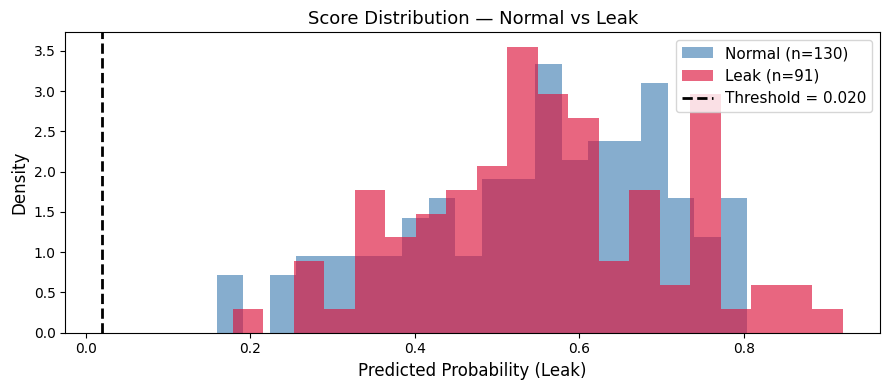

 Saved → fig_score_distribution.png


In [7]:
# Shows how well the model separates Normal vs Leak probabilities
normal_proba = y_proba[y_test == 0]
leak_proba   = y_proba[y_test == 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(normal_proba, bins=20, alpha=0.65, color="steelblue",
        label=f"Normal (n={len(normal_proba)})", density=True)
ax.hist(leak_proba,   bins=20, alpha=0.65, color="crimson",
        label=f"Leak (n={len(leak_proba)})",     density=True)
ax.axvline(THRESHOLD, linestyle="--", color="black", lw=2,
           label=f"Threshold = {THRESHOLD:.3f}")
ax.set_xlabel("Predicted Probability (Leak)", fontsize=12)
ax.set_ylabel("Density",                      fontsize=12)
ax.set_title("Score Distribution — Normal vs Leak", fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(" Saved → fig_score_distribution.png")


In [8]:
print("=" * 50)
print("  PAPER-READY NUMBERS (copy into Section 5)")
print("=" * 50)
print(f"""
The CNN-BiLSTM model with temporal attention achieves:

  • AUC-ROC  = {auc_roc:.4f}
  • AUC-PR   = {auc_pr:.4f}

At threshold τ = {THRESHOLD:.4f} (recall-optimized on calibration set):

  • Precision (Leak) = {report['Leak']['precision']:.4f}
  • Recall    (Leak) = {report['Leak']['recall']:.4f}
  • F1-score  (Leak) = {report['Leak']['f1-score']:.4f}
  • Overall Accuracy = {report['accuracy']:.4f}

Confusion Matrix:
{confusion_matrix(y_test, y_pred)}
""")


  PAPER-READY NUMBERS (copy into Section 5)

The CNN-BiLSTM model with temporal attention achieves:

  • AUC-ROC  = 0.5011
  • AUC-PR   = 0.4552

At threshold τ = 0.0200 (recall-optimized on calibration set):

  • Precision (Leak) = 0.4118
  • Recall    (Leak) = 1.0000
  • F1-score  (Leak) = 0.5833
  • Overall Accuracy = 0.4118

Confusion Matrix:
[[  0 130]
 [  0  91]]

